In [1]:
# =============================================================
# TRABAJO DE FIN DE MÁSTER — MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA
# Universidad Internacional del Ecuador (UIDE)
#
# Título: Comparación de modelos de aprendizaje automático para
#         predecir el tiempo de llegada entre paradas en el
#         sistema BRT Ecovía de Quito utilizando registros
#         históricos de GPS
#
# Autores: Ortega Campus Jhon Henry 
#          Ramos Mayorga Oscar Andrés
#          Torres Chango Christian Damian
#
# Notebook 01 — Análisis Exploratorio de Datos (EDA)
#
# Descripción:
# Este notebook realiza el análisis exploratorio del dataset
# histórico de GPS del sistema BRT Ecovía de Quito,
# proporcionado por Mivilsoft S.A. mediante el sistema SAE.
# Se analizan la variable objetivo eta_next_stop, las variables
# temporales, operacionales y espaciales, con el objetivo de
# identificar patrones, valores atípicos y decisiones de
# preprocesamiento para el entrenamiento de los modelos.
#
# Período del dataset: 15/09/2025 — 15/03/2026
# Registros originales: 28,011,776
# Rutas analizadas: E1, E1M, E2_NS, E2_SN, E3_NS, E3_SN, E4
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("=" * 60)
print("Notebook 01 — Análisis Exploratorio de Datos")
print("Sistema BRT Ecovía de Quito")
print("=" * 60)
print("Librerías importadas correctamente.")

Notebook 01 — Análisis Exploratorio de Datos
Sistema BRT Ecovía de Quito
Librerías importadas correctamente.


In [2]:
# =============================================================
# Carga del dataset
# Se carga el dataset histórico completo de operación del
# sistema Ecovía proporcionado por Mivilsoft S.A. mediante
# el sistema de Ayuda a la Explotación (SAE).
#
# Fuente:  Mivilsoft S.A.
# Período: 15/09/2025 — 15/03/2026
# Tamaño:  28,011,776 registros × 36 columnas
# Rutas:   E1(55), E1M(58), E2_NS(59), E2_SN(57),
#          E3_NS(56), E3_SN(62), E4(60)
# =============================================================

RUTA = 'dataset_completo.csv'

df = pd.read_csv(RUTA)

print(f"Dataset cargado correctamente.")
print(f"Dimensiones:   {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nPrimeros registros:")
print(df.head(3))

Dataset cargado correctamente.
Dimensiones:   28,011,776 filas × 36 columnas

Columnas disponibles:
['bus_id', 'timestamp', 'latitude', 'longitude', 'altitude', 'speed', 'course', 'accuracy', 'valid', 'trip_id', 'start_time', 'end_time', 'date', 'route_id', 'current_stop_id', 'current_stop_order', 'bus_stop_lat', 'bus_stop_lng', 'step_time', 'scheduled_passing_time', 'real_passing_time', 'last_stop_time', 'next_stop_order', 'next_stop_id', 'next_stop_time', 'next_stop_lat', 'next_stop_lng', 'time_since_last_stop', 'distance_to_next_stop', 'acceleration', 'hour', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_holiday', 'eta_next_stop']

Tipos de datos:
bus_id                      int64
timestamp                     str
latitude                  float64
longitude                 float64
altitude                    int64
speed                     float64
course                    float64
accuracy                    int64
valid                         str
trip_id                     int6

In [3]:
# =============================================================
# Verificación inicial del dataset
# Se revisan tipos de datos y valores nulos para obtener
# una visión general de la estructura del dataset antes
# de iniciar el análisis exploratorio.
# =============================================================

print("=" * 60)
print("VERIFICACIÓN INICIAL DEL DATASET")
print("=" * 60)

print(f"\nDimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

print("\n--- Tipos de datos ---")
print(df.dtypes)

print("\n--- Valores nulos por variable ---")
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin valores nulos.")
print(f"\nTotal valores nulos: {nulos.sum():,}")

VERIFICACIÓN INICIAL DEL DATASET

Dimensiones: 28,011,776 filas × 36 columnas

--- Tipos de datos ---
bus_id                      int64
timestamp                     str
latitude                  float64
longitude                 float64
altitude                    int64
speed                     float64
course                    float64
accuracy                    int64
valid                         str
trip_id                     int64
start_time                    str
end_time                      str
date                          str
route_id                  float64
current_stop_id           float64
current_stop_order        float64
bus_stop_lat              float64
bus_stop_lng              float64
step_time                 float64
scheduled_passing_time    float64
real_passing_time         float64
last_stop_time                str
next_stop_order           float64
next_stop_id              float64
next_stop_time                str
next_stop_lat             float64
next_stop_lng 

In [4]:
# =============================================================
# Análisis de la variable objetivo: eta_next_stop
# Se analiza la distribución del tiempo de llegada entre
# paradas para identificar el comportamiento general del
# sistema y detectar valores atípicos que requieran
# tratamiento en el preprocesamiento.
# =============================================================

print("=" * 60)
print("VARIABLE OBJETIVO: eta_next_stop")
print("=" * 60)

stats = df['eta_next_stop'].describe()

print("\n--- Estadísticas descriptivas ---")
print(f"  Registros:          {stats['count']:>15,.0f}")
print(f"  Promedio:           {stats['mean']:>15.3f} minutos")
print(f"  Desviación estándar:{stats['std']:>15.3f} minutos")
print(f"  Mínimo:             {stats['min']:>15.3f} minutos")
print(f"  Percentil 25%:      {stats['25%']:>15.3f} minutos")
print(f"  Mediana:            {stats['50%']:>15.3f} minutos")
print(f"  Percentil 75%:      {stats['75%']:>15.3f} minutos")
print(f"  Máximo:             {stats['max']:>15.3f} minutos")

print(f"\n--- Valores especiales ---")
print(f"  Valores negativos:    {(df['eta_next_stop'] < 0).sum():,}")
print(f"  Valores en cero:      {(df['eta_next_stop'] == 0).sum():,}")
print(f"  Valores > 10 minutos: {(df['eta_next_stop'] > 10).sum():,} "
      f"({(df['eta_next_stop'] > 10).sum()/len(df)*100:.2f}%)")
print(f"  Valores > 60 minutos: {(df['eta_next_stop'] > 60).sum():,} "
      f"({(df['eta_next_stop'] > 60).sum()/len(df)*100:.2f}%)")

print(f"\n  Nota: Los valores mayores a 10 minutos serán")
print(f"  eliminados por ruta en el preprocesamiento.")

VARIABLE OBJETIVO: eta_next_stop

--- Estadísticas descriptivas ---
  Registros:               28,011,776
  Promedio:                     1.835 minutos
  Desviación estándar:          4.483 minutos
  Mínimo:                       0.017 minutos
  Percentil 25%:                0.467 minutos
  Mediana:                      0.983 minutos
  Percentil 75%:                1.850 minutos
  Máximo:                     138.033 minutos

--- Valores especiales ---
  Valores negativos:    0
  Valores en cero:      0
  Valores > 10 minutos: 501,004 (1.79%)
  Valores > 60 minutos: 42,341 (0.15%)

  Nota: Los valores mayores a 10 minutos serán
  eliminados por ruta en el preprocesamiento.


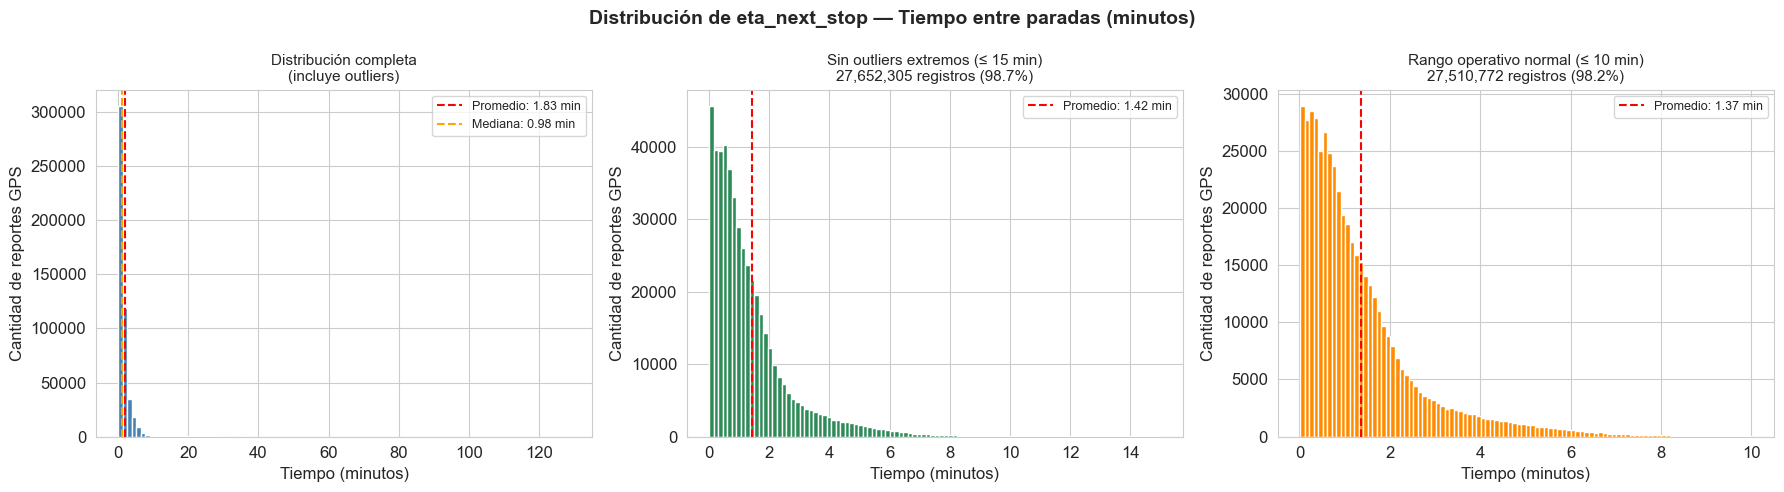

RESUMEN — Distribución de eta_next_stop
  Registros totales:           28,011,776
  Registros con eta ≤ 15 min: 27,652,305 (98.72%)
  Registros con eta ≤ 10 min: 27,510,772 (98.21%)
  Registros con eta > 15 min: 359,471 (1.28%)

  Nota: Las estadísticas se calculan sobre el dataset
  completo. La visualización usa una muestra de
  500,000 registros para optimizar el uso de memoria.


9

In [5]:
# =============================================================
# Análisis visual de la variable objetivo: eta_next_stop
# Se visualiza la distribución del tiempo de llegada entre
# paradas para identificar el comportamiento real del sistema
# y confirmar los valores atípicos detectados.
# Se utiliza una muestra de 500,000 registros para la
# visualización sin afectar la representatividad del análisis.
# =============================================================

import gc
gc.collect()

# Muestra para visualización
df_muestra = df.sample(n=500_000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de eta_next_stop — Tiempo entre paradas (minutos)',
             fontsize=14, fontweight='bold')

# Gráfica 1 — Distribución completa
axes[0].hist(df_muestra['eta_next_stop'], bins=100,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribución completa\n(incluye outliers)', fontsize=11)
axes[0].set_xlabel('Tiempo (minutos)')
axes[0].set_ylabel('Cantidad de reportes GPS')
axes[0].axvline(df['eta_next_stop'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Promedio: {df['eta_next_stop'].mean():.2f} min")
axes[0].axvline(df['eta_next_stop'].median(), color='orange',
                linestyle='--', linewidth=1.5,
                label=f"Mediana: {df['eta_next_stop'].median():.2f} min")
axes[0].legend(fontsize=9)

# Gráfica 2 — Sin outliers extremos
df_limpio = df_muestra[df_muestra['eta_next_stop'] <= 15]
axes[1].hist(df_limpio['eta_next_stop'], bins=100,
             color='seagreen', edgecolor='white')
axes[1].set_title(f'Sin outliers extremos (≤ 15 min)\n'
                  f'{len(df[df.eta_next_stop<=15]):,} registros '
                  f'({len(df[df.eta_next_stop<=15])/len(df)*100:.1f}%)',
                  fontsize=11)
axes[1].set_xlabel('Tiempo (minutos)')
axes[1].set_ylabel('Cantidad de reportes GPS')
axes[1].axvline(df[df.eta_next_stop<=15]['eta_next_stop'].mean(),
                color='red', linestyle='--', linewidth=1.5,
                label=f"Promedio: {df[df.eta_next_stop<=15]['eta_next_stop'].mean():.2f} min")
axes[1].legend(fontsize=9)

# Gráfica 3 — Rango operativo normal
df_normal = df_muestra[df_muestra['eta_next_stop'] <= 10]
axes[2].hist(df_normal['eta_next_stop'], bins=100,
             color='darkorange', edgecolor='white')
axes[2].set_title(f'Rango operativo normal (≤ 10 min)\n'
                  f'{len(df[df.eta_next_stop<=10]):,} registros '
                  f'({len(df[df.eta_next_stop<=10])/len(df)*100:.1f}%)',
                  fontsize=11)
axes[2].set_xlabel('Tiempo (minutos)')
axes[2].set_ylabel('Cantidad de reportes GPS')
axes[2].axvline(df[df.eta_next_stop<=10]['eta_next_stop'].mean(),
                color='red', linestyle='--', linewidth=1.5,
                label=f"Promedio: {df[df.eta_next_stop<=10]['eta_next_stop'].mean():.2f} min")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('distribucion_eta.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 55)
print("RESUMEN — Distribución de eta_next_stop")
print("=" * 55)
print(f"  Registros totales:           {len(df):,}")
print(f"  Registros con eta ≤ 15 min: {len(df[df.eta_next_stop<=15]):,} "
      f"({len(df[df.eta_next_stop<=15])/len(df)*100:.2f}%)")
print(f"  Registros con eta ≤ 10 min: {len(df[df.eta_next_stop<=10]):,} "
      f"({len(df[df.eta_next_stop<=10])/len(df)*100:.2f}%)")
print(f"  Registros con eta > 15 min: {len(df[df.eta_next_stop>15]):,} "
      f"({len(df[df.eta_next_stop>15])/len(df)*100:.2f}%)")
print(f"\n  Nota: Las estadísticas se calculan sobre el dataset")
print(f"  completo. La visualización usa una muestra de")
print(f"  500,000 registros para optimizar el uso de memoria.")

del df_muestra, df_limpio, df_normal
gc.collect()

 Ruta E1: 29,921 segmentos procesados
 Ruta E1M: 22,893 segmentos procesados
 Ruta E2_NS: 23,766 segmentos procesados
 Ruta E2_SN: 12,909 segmentos procesados
 Ruta E3_NS: 11,446 segmentos procesados
 Ruta E3_SN: 23,785 segmentos procesados
 Ruta E4: 16,046 segmentos procesados

 Todas las rutas procesadas


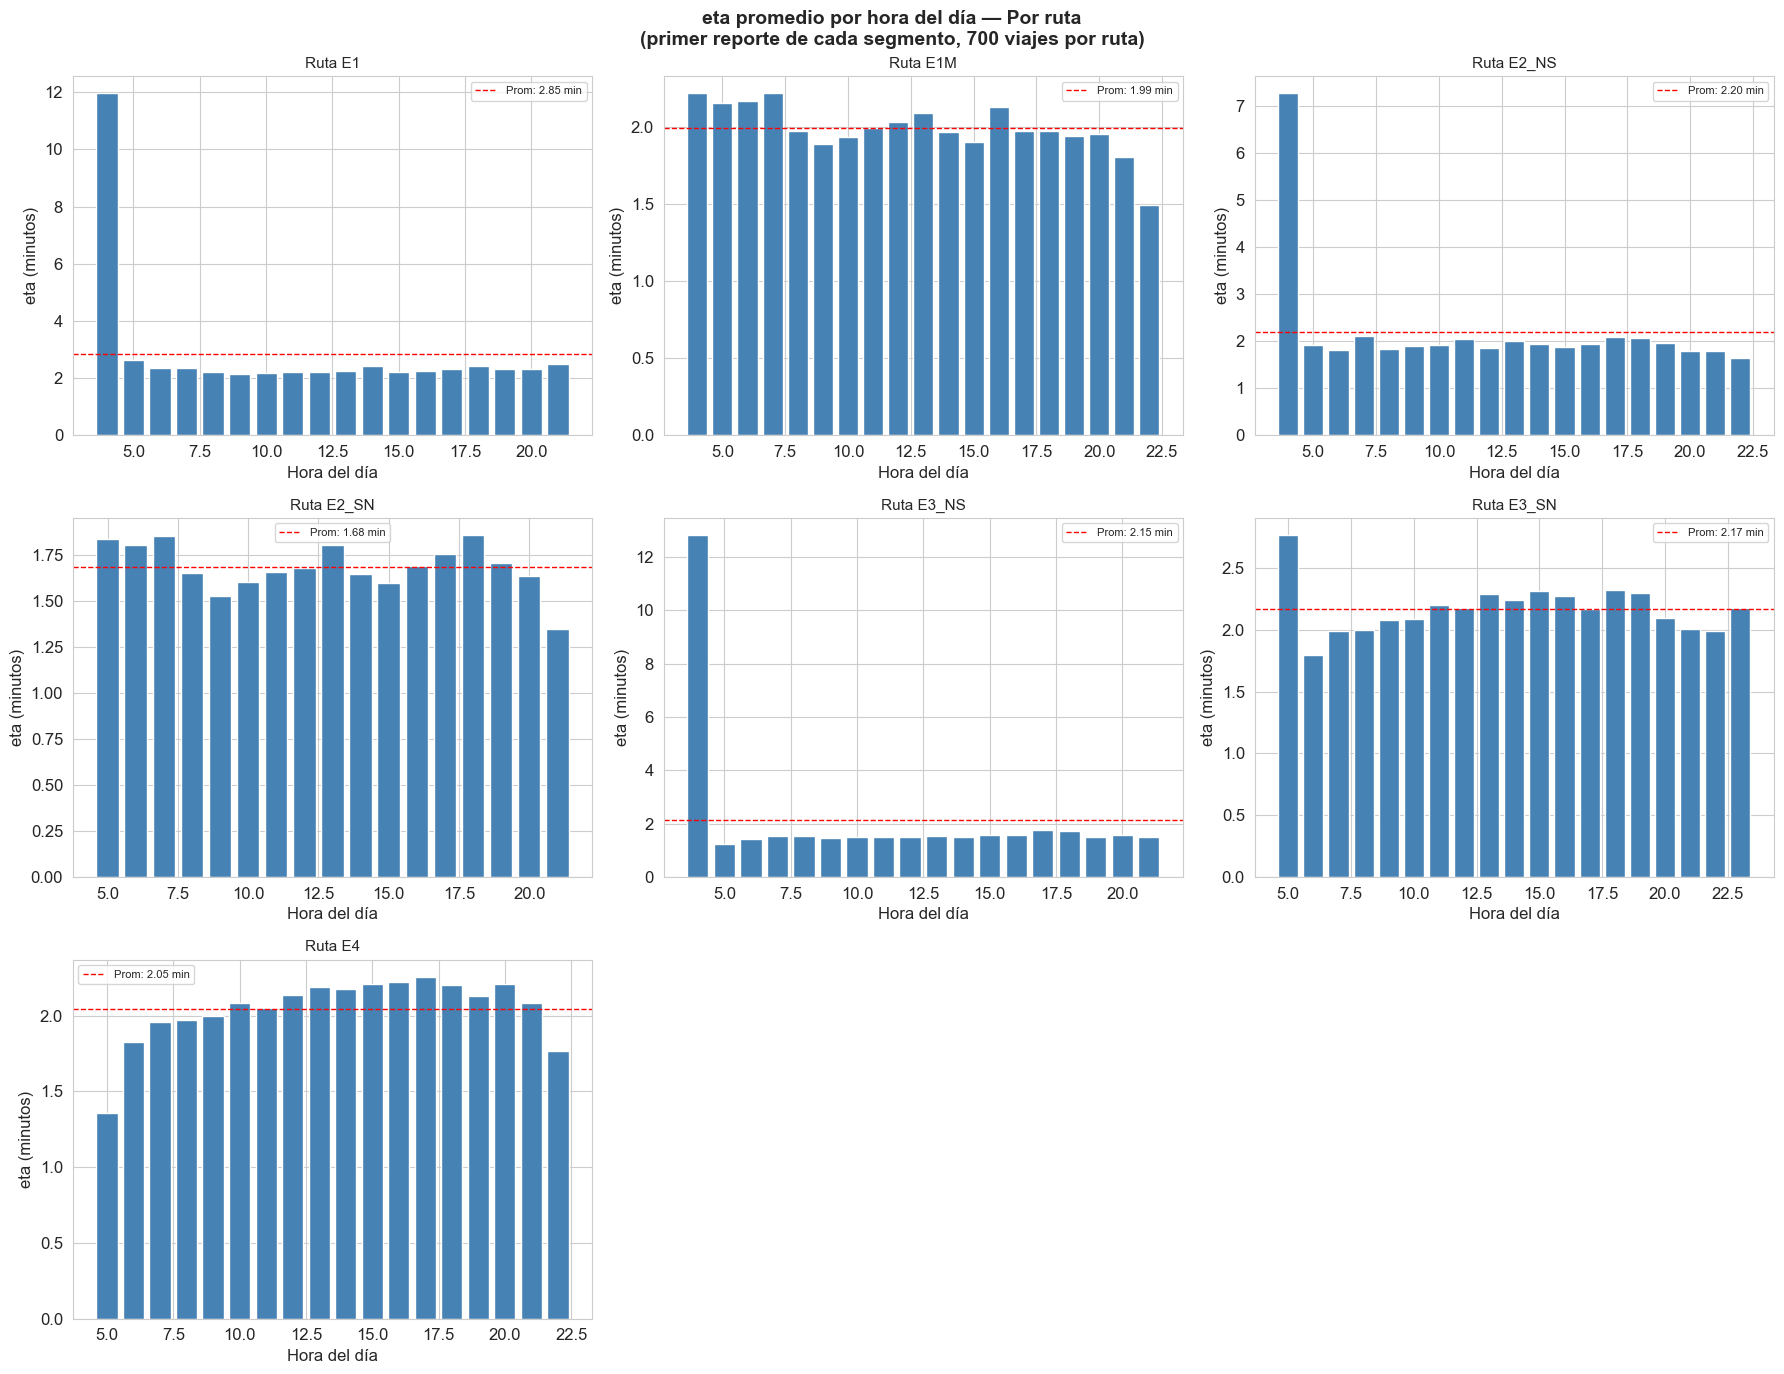


=== HORA PICO VS NO PICO POR RUTA ===
  E1: No pico=2.278 min  Hora pico=2.305 min
  E1M: No pico=2.016 min  Hora pico=2.008 min
  E2_NS: No pico=1.903 min  Hora pico=1.997 min
  E2_SN: No pico=1.690 min  Hora pico=1.725 min
  E3_NS: No pico=1.488 min  Hora pico=1.594 min
  E3_SN: No pico=2.127 min  Hora pico=2.144 min
  E4: No pico=2.124 min  Hora pico=2.093 min


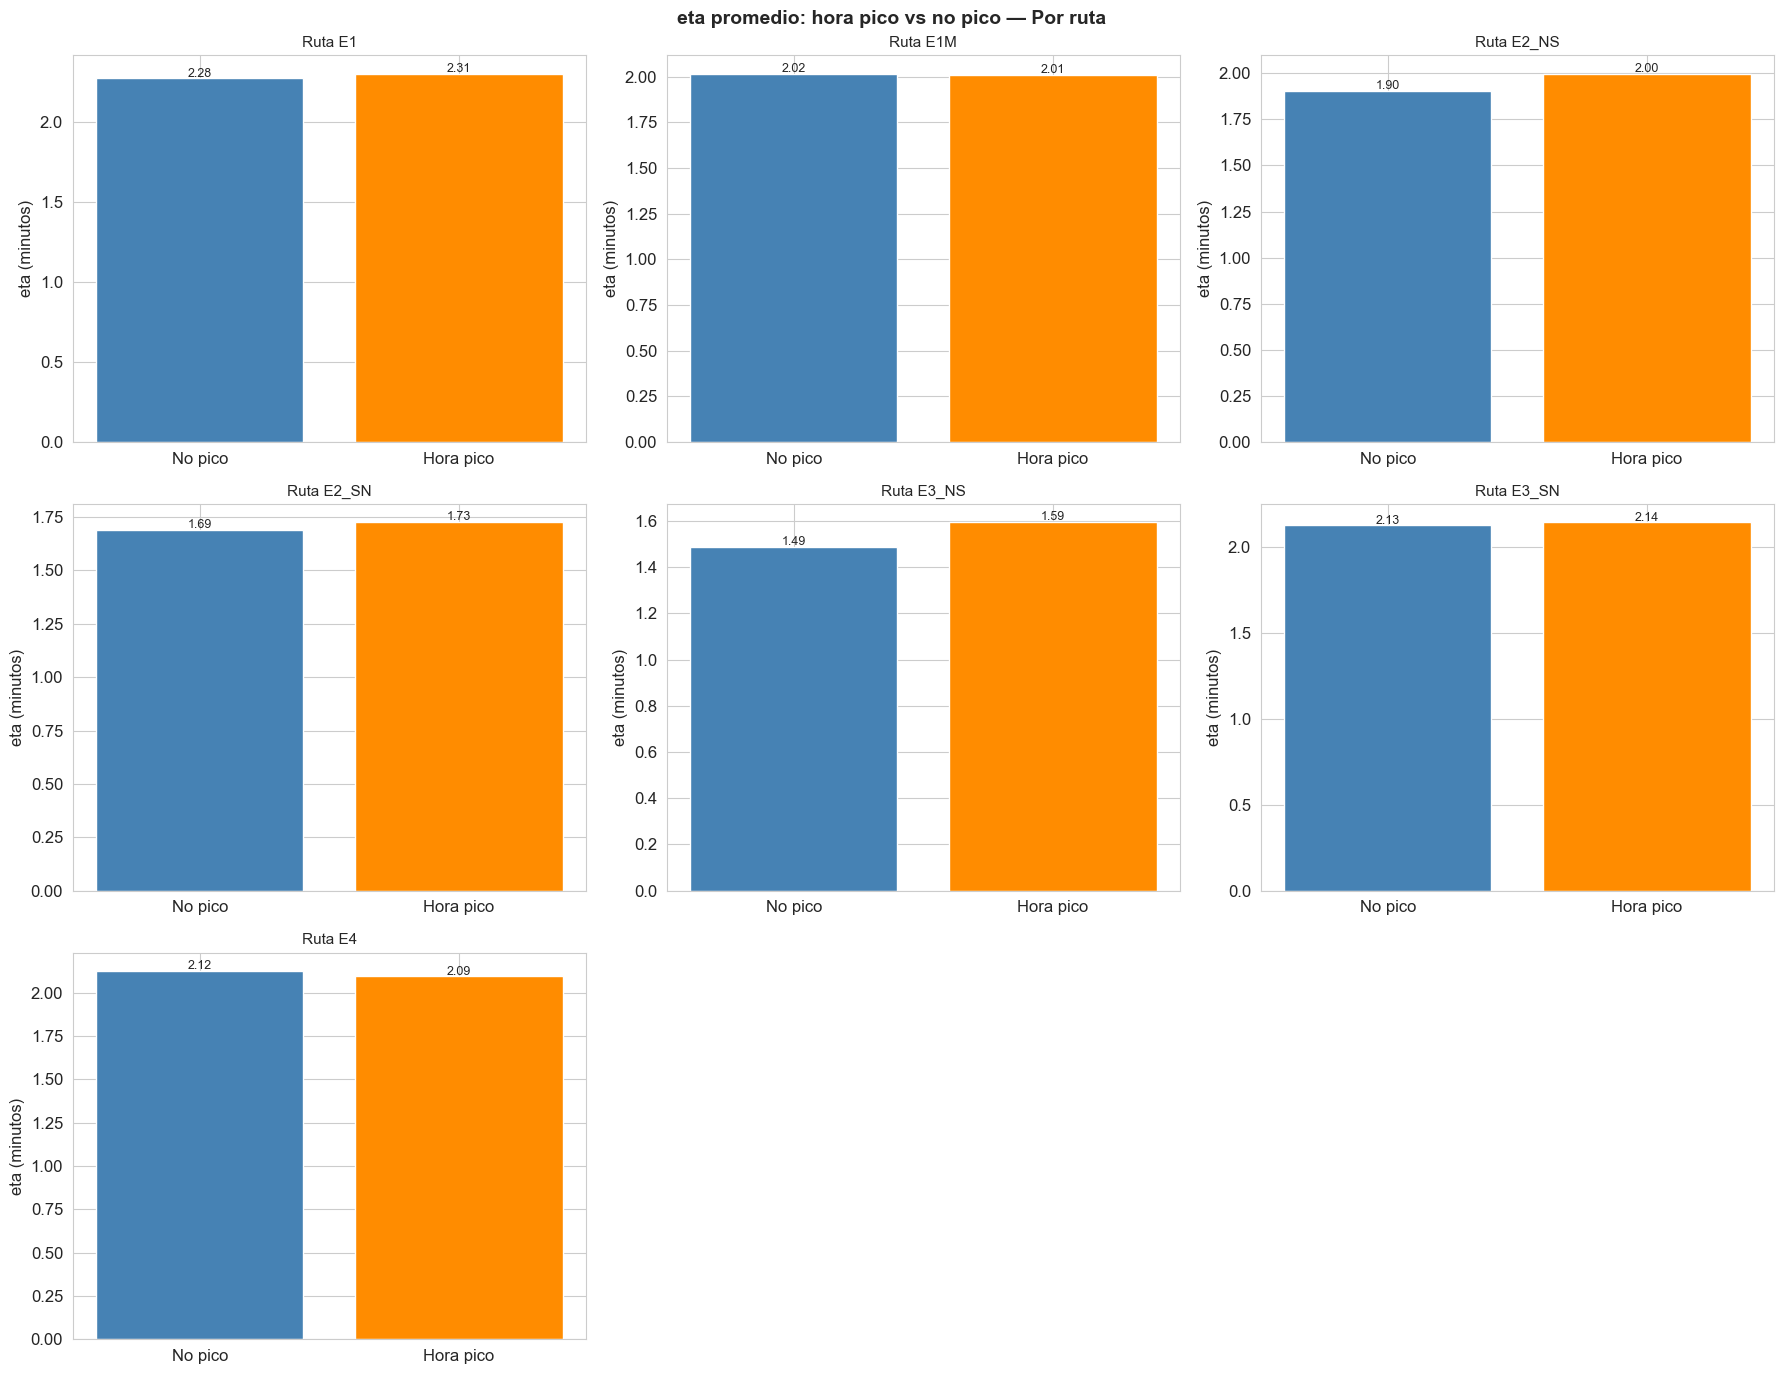


=== LABORAL VS FIN DE SEMANA POR RUTA ===
  E1: Laboral=2.309 min  Fin de semana=2.186 min
  E1M: Laboral=2.027 min  Fin de semana=1.938 min
  E2_NS: Laboral=1.958 min  Fin de semana=1.856 min
  E2_SN: Laboral=1.732 min  Fin de semana=1.586 min
  E3_NS: Laboral=1.544 min  Fin de semana=1.471 min
  E3_SN: Laboral=2.081 min  Fin de semana=2.165 min
  E4: Laboral=2.170 min  Fin de semana=2.073 min


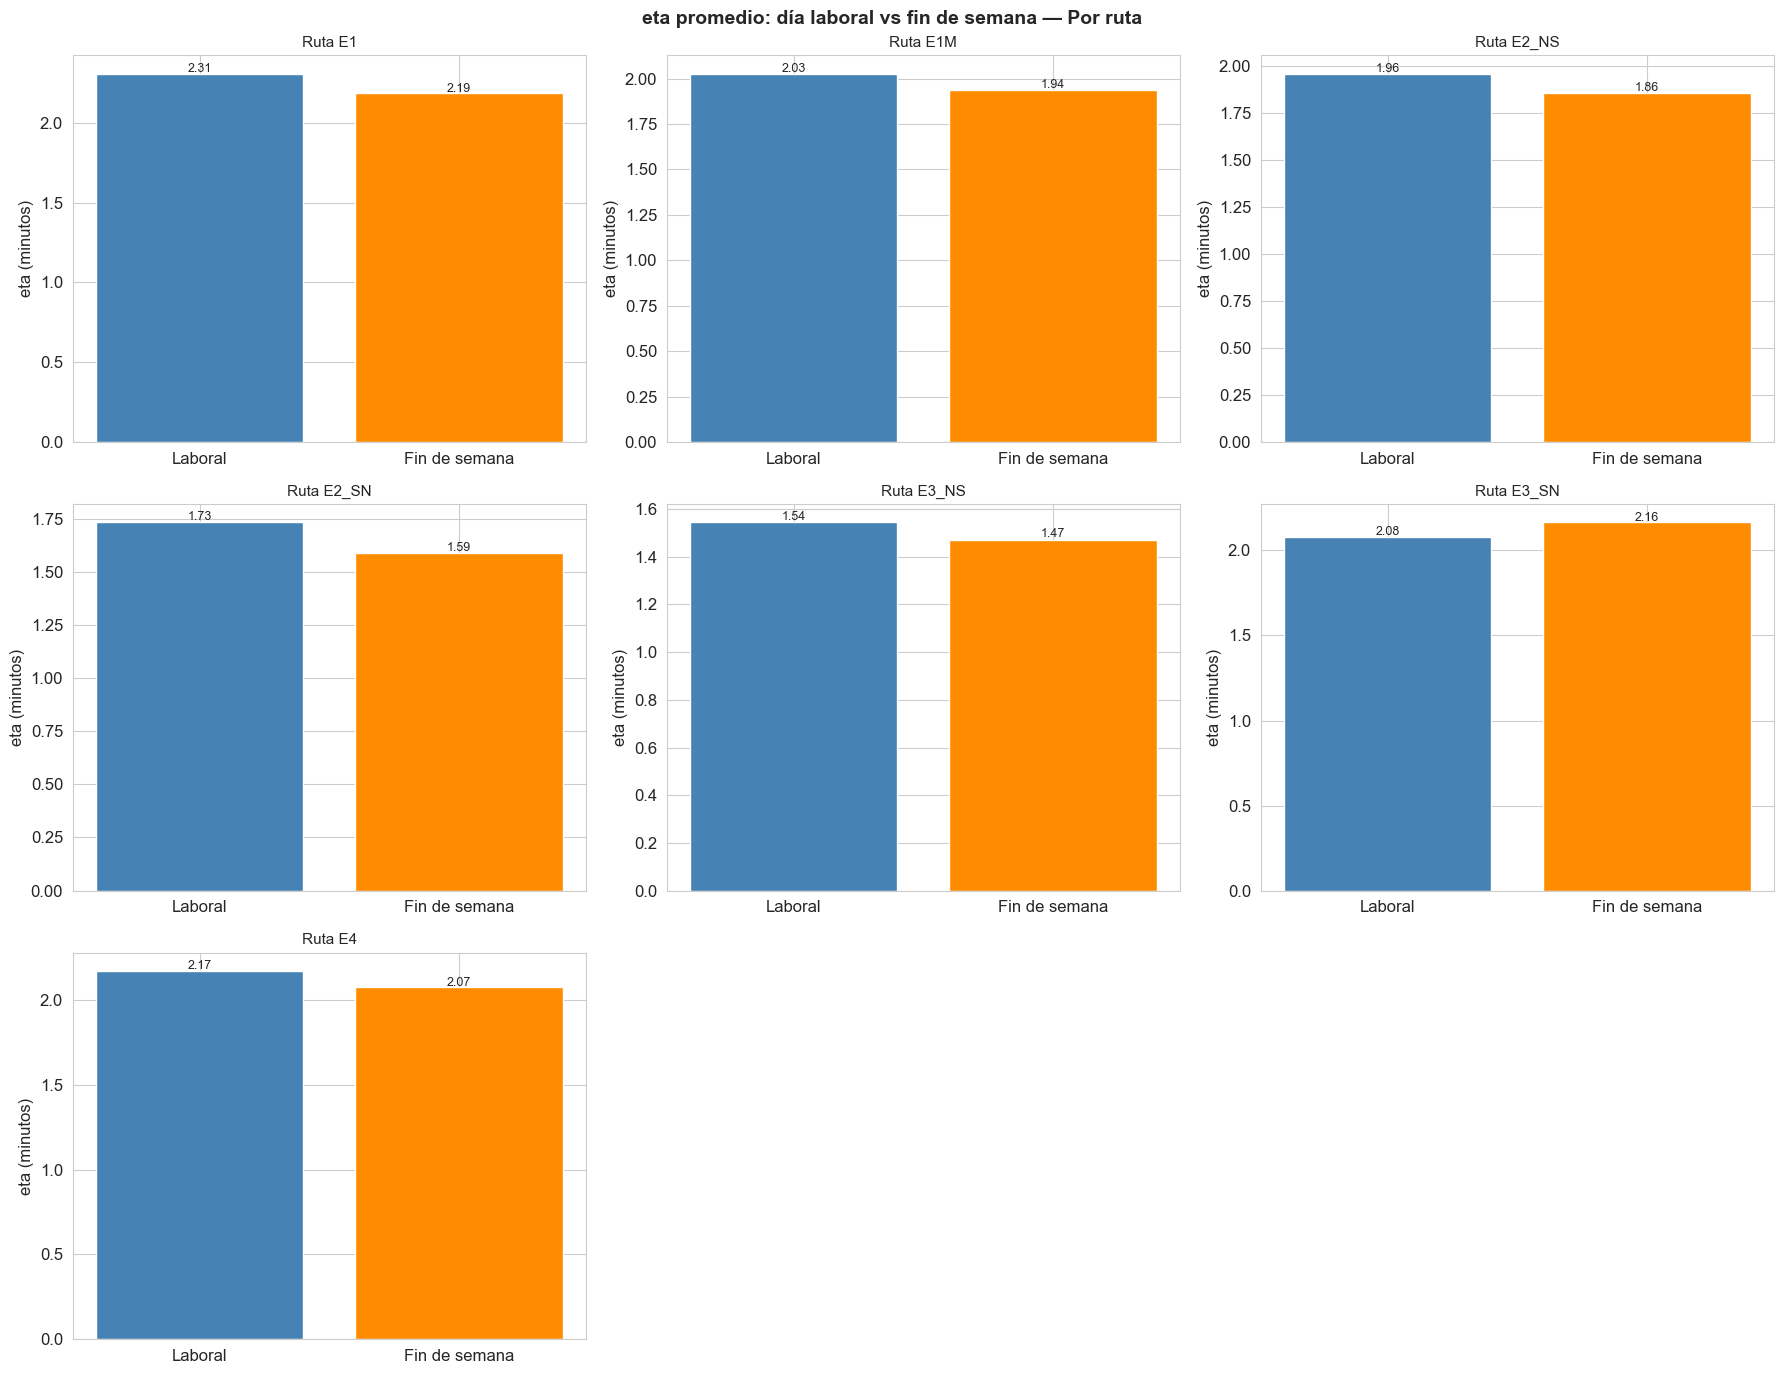

76025

In [6]:
# =============================================================
# Análisis del impacto de variables temporales en eta_next_stop
# Se analiza por ruta separada para identificar patrones
# relevantes y justificar las variables del modelo.
# Se procesan 700 viajes por ruta de forma secuencial
# =============================================================

import gc
gc.collect()

rutas_nombres = {
    55.0: 'E1', 58.0: 'E1M', 59.0: 'E2_NS',
    57.0: 'E2_SN', 56.0: 'E3_NS', 62.0: 'E3_SN', 60.0: 'E4'
}

resultados_temporales = {}

for route_id, nombre_ruta in rutas_nombres.items():

    # Filtrar solo la ruta actual
    df_ruta = df[df['route_id'] == route_id]

    # Seleccionar 700 viajes de esa ruta
    viajes_ruta = df_ruta['trip_id'].drop_duplicates()
    n = min(700, len(viajes_ruta))
    viajes_muestra = viajes_ruta.sample(n=n, random_state=42)
    df_muestra = df_ruta[df_ruta['trip_id'].isin(viajes_muestra)].copy()
    df_muestra['timestamp'] = pd.to_datetime(df_muestra['timestamp'])

    # Primer reporte de cada segmento
    df_segmentos = (df_muestra.sort_values('timestamp')
                               .groupby(['trip_id', 'current_stop_id'])
                               .first()
                               .reset_index())

    # Guardar resultados
    resultados_temporales[nombre_ruta] = {
        'eta_hora':    df_segmentos.groupby('hour')['eta_next_stop'].mean(),
        'eta_dia':     df_segmentos.groupby('day_of_week')['eta_next_stop'].mean(),
        'eta_pico':    df_segmentos.groupby('is_peak_hour')['eta_next_stop'].mean(),
        'eta_fds':     df_segmentos.groupby('is_weekend')['eta_next_stop'].mean(),
        'segmentos':   len(df_segmentos)
    }

    print(f" Ruta {nombre_ruta}: {len(df_segmentos):,} segmentos procesados")

    del df_ruta, df_muestra, df_segmentos
    gc.collect()

print("\n Todas las rutas procesadas")

# =============================================================
# Gráfica 1 — eta por hora del día por ruta
# =============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('eta promedio por hora del día — Por ruta\n'
             '(primer reporte de cada segmento, 700 viajes por ruta)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (nombre_ruta, datos) in enumerate(resultados_temporales.items()):
    eta_hora = datos['eta_hora']
    axes[i].bar(eta_hora.index, eta_hora.values, color='steelblue')
    axes[i].set_title(f'Ruta {nombre_ruta}', fontsize=11)
    axes[i].set_xlabel('Hora del día')
    axes[i].set_ylabel('eta (minutos)')
    axes[i].axhline(eta_hora.mean(), color='red', linestyle='--',
                    linewidth=1, label=f'Prom: {eta_hora.mean():.2f} min')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
axes[-2].set_visible(False)
plt.tight_layout()
plt.savefig('eta_por_hora_por_ruta.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================
# Gráfica 2 — hora pico vs no pico por ruta
# =============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('eta promedio: hora pico vs no pico — Por ruta',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

print("\n=== HORA PICO VS NO PICO POR RUTA ===")
for i, (nombre_ruta, datos) in enumerate(resultados_temporales.items()):
    eta_pico = datos['eta_pico']
    axes[i].bar(['No pico', 'Hora pico'], eta_pico.values,
                color=['steelblue', 'darkorange'])
    axes[i].set_title(f'Ruta {nombre_ruta}', fontsize=11)
    axes[i].set_ylabel('eta (minutos)')
    for j, v in enumerate(eta_pico.values):
        axes[i].text(j, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
    print(f"  {nombre_ruta}: No pico={eta_pico.iloc[0]:.3f} min  "
          f"Hora pico={eta_pico.iloc[1]:.3f} min")

axes[-1].set_visible(False)
axes[-2].set_visible(False)
plt.tight_layout()
plt.savefig('eta_hora_pico_por_ruta.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================
# Gráfica 3 — laboral vs fin de semana por ruta
# =============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('eta promedio: día laboral vs fin de semana — Por ruta',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

print("\n=== LABORAL VS FIN DE SEMANA POR RUTA ===")
for i, (nombre_ruta, datos) in enumerate(resultados_temporales.items()):
    eta_fds = datos['eta_fds']
    axes[i].bar(['Laboral', 'Fin de semana'], eta_fds.values,
                color=['steelblue', 'darkorange'])
    axes[i].set_title(f'Ruta {nombre_ruta}', fontsize=11)
    axes[i].set_ylabel('eta (minutos)')
    for j, v in enumerate(eta_fds.values):
        axes[i].text(j, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
    print(f"  {nombre_ruta}: Laboral={eta_fds.iloc[0]:.3f} min  "
          f"Fin de semana={eta_fds.iloc[1]:.3f} min")

axes[-1].set_visible(False)
axes[-2].set_visible(False)
plt.tight_layout()
plt.savefig('eta_fds_por_ruta.png', dpi=150, bbox_inches='tight')
plt.show()

gc.collect()

In [7]:
# =============================================================
# Resultados numéricos detallados por ruta
# =============================================================
print("\n" + "=" * 60)
print("ETA PROMEDIO POR HORA — DETALLE POR RUTA")
print("=" * 60)
for nombre_ruta, datos in resultados_temporales.items():
    print(f"\nRuta {nombre_ruta}:")
    print(datos['eta_hora'].round(3).to_string())

print("\n" + "=" * 60)
print("HORA PICO VS NO PICO — DETALLE POR RUTA")
print("=" * 60)
for nombre_ruta, datos in resultados_temporales.items():
    eta_pico = datos['eta_pico']
    print(f"\nRuta {nombre_ruta}:")
    print(f"  No pico:   {eta_pico.iloc[0]:.3f} min")
    print(f"  Hora pico: {eta_pico.iloc[1]:.3f} min")

print("\n" + "=" * 60)
print("LABORAL VS FIN DE SEMANA — DETALLE POR RUTA")
print("=" * 60)
for nombre_ruta, datos in resultados_temporales.items():
    eta_fds = datos['eta_fds']
    print(f"\nRuta {nombre_ruta}:")
    print(f"  Laboral:        {eta_fds.iloc[0]:.3f} min")
    print(f"  Fin de semana:  {eta_fds.iloc[1]:.3f} min")


ETA PROMEDIO POR HORA — DETALLE POR RUTA

Ruta E1:
hour
4     11.967
5      2.629
6      2.360
7      2.359
8      2.222
9      2.151
10     2.167
11     2.201
12     2.221
13     2.257
14     2.408
15     2.208
16     2.254
17     2.330
18     2.435
19     2.315
20     2.317
21     2.477

Ruta E1M:
hour
4     2.217
5     2.153
6     2.170
7     2.218
8     1.973
9     1.891
10    1.935
11    1.994
12    2.033
13    2.092
14    1.969
15    1.905
16    2.127
17    1.972
18    1.972
19    1.941
20    1.955
21    1.802
22    1.492

Ruta E2_NS:
hour
4     7.281
5     1.928
6     1.811
7     2.113
8     1.830
9     1.908
10    1.922
11    2.052
12    1.853
13    2.017
14    1.933
15    1.877
16    1.951
17    2.096
18    2.074
19    1.963
20    1.799
21    1.794
22    1.654

Ruta E2_SN:
hour
5     1.837
6     1.801
7     1.850
8     1.648
9     1.525
10    1.601
11    1.657
12    1.677
13    1.801
14    1.644
15    1.598
16    1.690
17    1.755
18    1.857
19    1.707
20    1.634
21    1.3

 Datos operacionales procesados por ruta


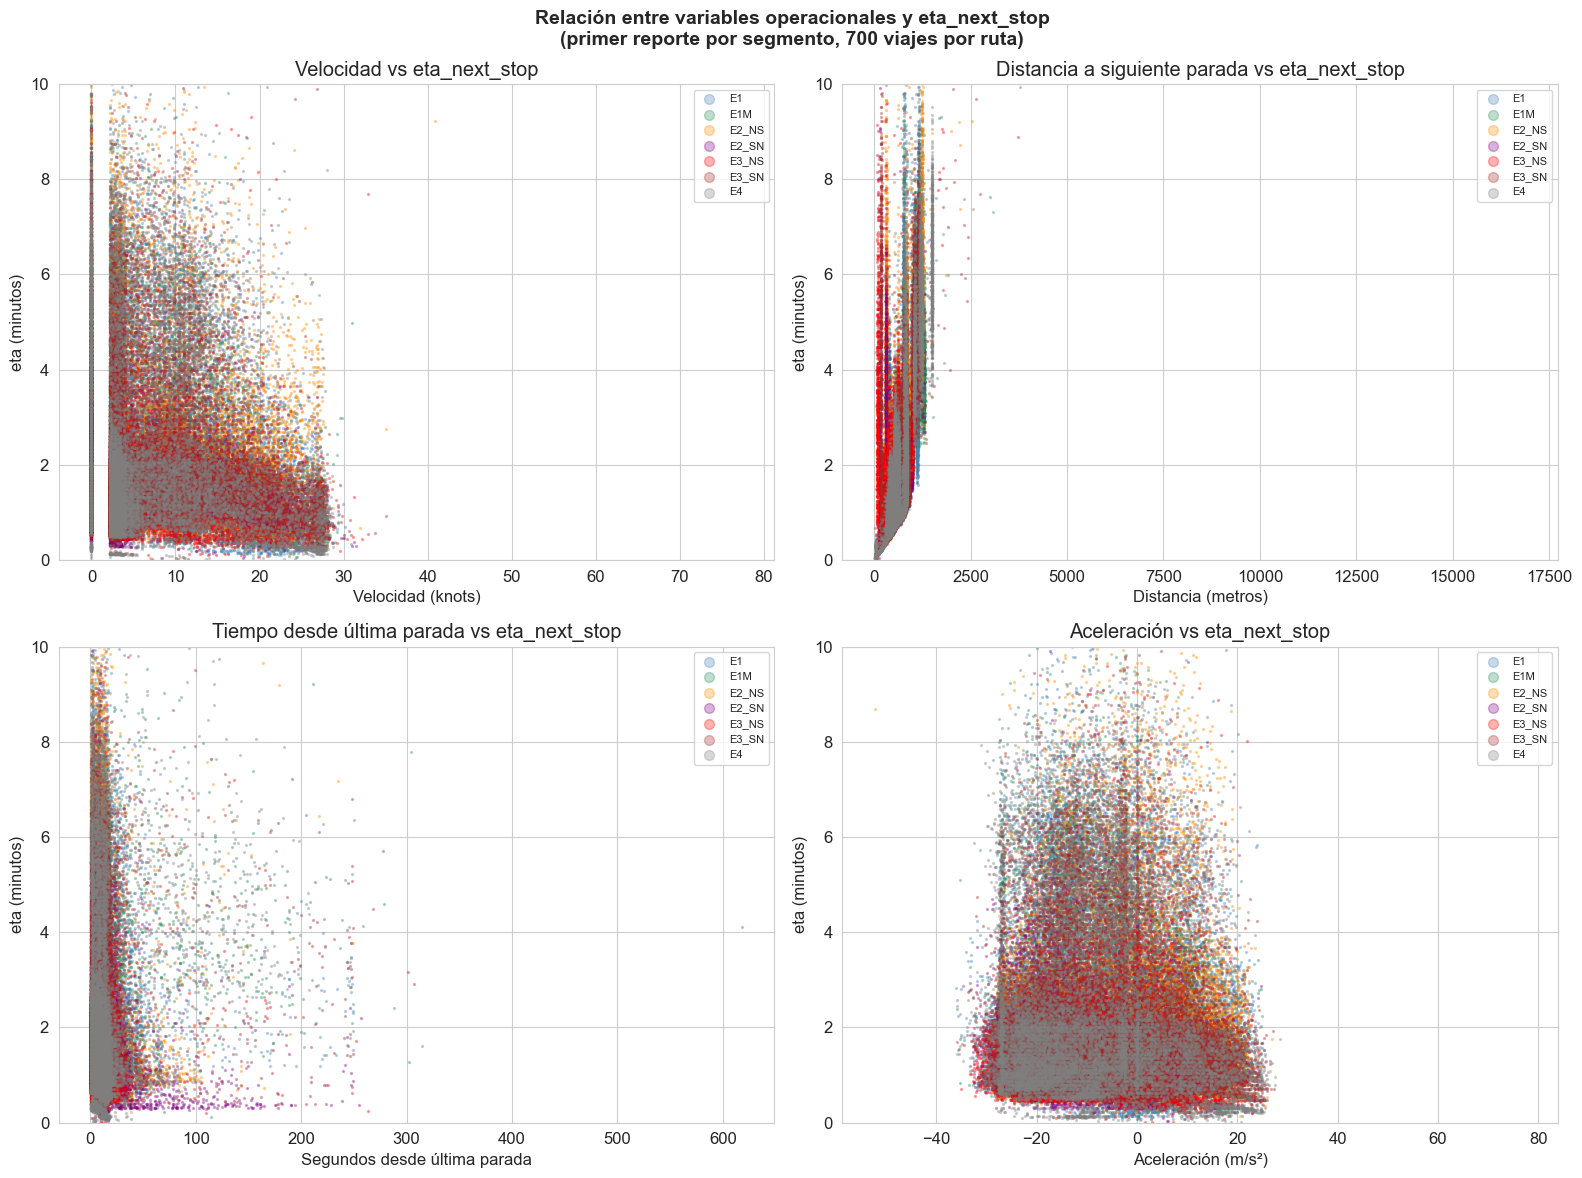


CORRELACIÓN CON eta_next_stop POR RUTA

Ruta E1:
  distance_to_next_stop       0.7102
  time_since_last_stop        0.0371
  acceleration               -0.0044
  speed                      -0.0609

Ruta E1M:
  distance_to_next_stop       0.5972
  acceleration                0.0636
  time_since_last_stop        0.0622
  speed                      -0.0154

Ruta E2_NS:
  distance_to_next_stop       0.5638
  acceleration                0.0961
  speed                       0.0470
  time_since_last_stop        0.0118

Ruta E2_SN:
  distance_to_next_stop       0.1159
  acceleration               -0.0290
  speed                      -0.0466
  time_since_last_stop       -0.0803

Ruta E3_NS:
  acceleration                0.1316
  distance_to_next_stop       0.1230
  time_since_last_stop        0.0101
  speed                      -0.0255

Ruta E3_SN:
  distance_to_next_stop       0.4874
  time_since_last_stop        0.0393
  acceleration               -0.0208
  speed                      -0.0895

19164

In [8]:
# =============================================================
# Análisis del impacto de variables operacionales en eta_next_stop
# Se analiza la relación entre velocidad, distancia,
# aceleración y tiempo desde última parada con el eta.
# Se procesan 700 viajes por ruta de forma secuencial
# para optimizar el uso de memoria RAM.
# =============================================================

import gc
gc.collect()

resultados_operacionales = {}

for route_id, nombre_ruta in rutas_nombres.items():

    df_ruta_orig = df[df['route_id'] == route_id]
    viajes_ruta  = df_ruta_orig['trip_id'].drop_duplicates()
    n = min(700, len(viajes_ruta))
    viajes_muestra = viajes_ruta.sample(n=n, random_state=42)
    df_muestra = df_ruta_orig[df_ruta_orig['trip_id'].isin(viajes_muestra)].copy()
    df_muestra['timestamp'] = pd.to_datetime(df_muestra['timestamp'])

    df_seg = (df_muestra.sort_values('timestamp')
                        .groupby(['trip_id', 'current_stop_id'])
                        .first()
                        .reset_index())

    resultados_operacionales[nombre_ruta] = df_seg[[
        'speed', 'distance_to_next_stop',
        'time_since_last_stop', 'acceleration',
        'eta_next_stop'
    ]].copy()

    del df_ruta_orig, df_muestra, df_seg
    gc.collect()

print(" Datos operacionales procesados por ruta")

# =============================================================
# Gráficas — variables operacionales vs eta por ruta
# =============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Relación entre variables operacionales y eta_next_stop\n'
             '(primer reporte por segmento, 700 viajes por ruta)',
             fontsize=14, fontweight='bold')

colores = ['steelblue', 'seagreen', 'darkorange',
           'purple', 'red', 'brown', 'gray']

for (nombre_ruta, datos), color in zip(
        resultados_operacionales.items(), colores):

    axes[0,0].scatter(datos['speed'], datos['eta_next_stop'],
                      alpha=0.3, s=2, color=color, label=nombre_ruta)
    axes[0,1].scatter(datos['distance_to_next_stop'], datos['eta_next_stop'],
                      alpha=0.3, s=2, color=color, label=nombre_ruta)
    axes[1,0].scatter(datos['time_since_last_stop'], datos['eta_next_stop'],
                      alpha=0.3, s=2, color=color, label=nombre_ruta)
    axes[1,1].scatter(datos['acceleration'], datos['eta_next_stop'],
                      alpha=0.3, s=2, color=color, label=nombre_ruta)

# Configurar ejes
axes[0,0].set_title('Velocidad vs eta_next_stop')
axes[0,0].set_xlabel('Velocidad (knots)')
axes[0,0].set_ylabel('eta (minutos)')
axes[0,0].set_ylim(0, 10)
axes[0,0].legend(markerscale=5, fontsize=8)

axes[0,1].set_title('Distancia a siguiente parada vs eta_next_stop')
axes[0,1].set_xlabel('Distancia (metros)')
axes[0,1].set_ylabel('eta (minutos)')
axes[0,1].set_ylim(0, 10)
axes[0,1].legend(markerscale=5, fontsize=8)

axes[1,0].set_title('Tiempo desde última parada vs eta_next_stop')
axes[1,0].set_xlabel('Segundos desde última parada')
axes[1,0].set_ylabel('eta (minutos)')
axes[1,0].set_ylim(0, 10)
axes[1,0].legend(markerscale=5, fontsize=8)

axes[1,1].set_title('Aceleración vs eta_next_stop')
axes[1,1].set_xlabel('Aceleración (m/s²)')
axes[1,1].set_ylabel('eta (minutos)')
axes[1,1].set_ylim(0, 10)
axes[1,1].legend(markerscale=5, fontsize=8)

plt.tight_layout()
plt.savefig('operacionales_vs_eta.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================
# Correlación numérica por ruta
# =============================================================
cols = ['speed', 'distance_to_next_stop',
        'time_since_last_stop', 'acceleration']

print("\n" + "=" * 60)
print("CORRELACIÓN CON eta_next_stop POR RUTA")
print("=" * 60)

for nombre_ruta, datos in resultados_operacionales.items():
    corr = datos[cols + ['eta_next_stop']].corr()['eta_next_stop'].drop('eta_next_stop')
    print(f"\nRuta {nombre_ruta}:")
    for var, val in corr.sort_values(ascending=False).items():
        print(f"  {var:<25} {val:>8.4f}")

del resultados_operacionales
gc.collect()

## Hallazgos - Variables operacionales

El análisis de correlación confirmó que la distancia 
a la siguiente parada es la variable operacional más 
predictiva del eta, con correlaciones entre 0.12 y 0.80 
según la ruta.

La velocidad, aceleración y tiempo desde la última parada 
presentan correlaciones bajas en el primer reporte de cada 
segmento, lo cual es esperado dado que estas variables 
cambian significativamente durante el recorrido. Sin embargo 
se incluyen en el modelo porque los modelos de secuencia 
temporal (LSTM y GRU) procesan la secuencia completa de 
reportes y pueden detectar patrones que la correlación 
lineal no captura. Los modelos de árbol (XGBoost y Gradient 
Boosting) también se benefician de estas variables al 
combinarlas con las 120 variables aplanadas de la ventana 
temporal.

 Datos espaciales procesados por ruta


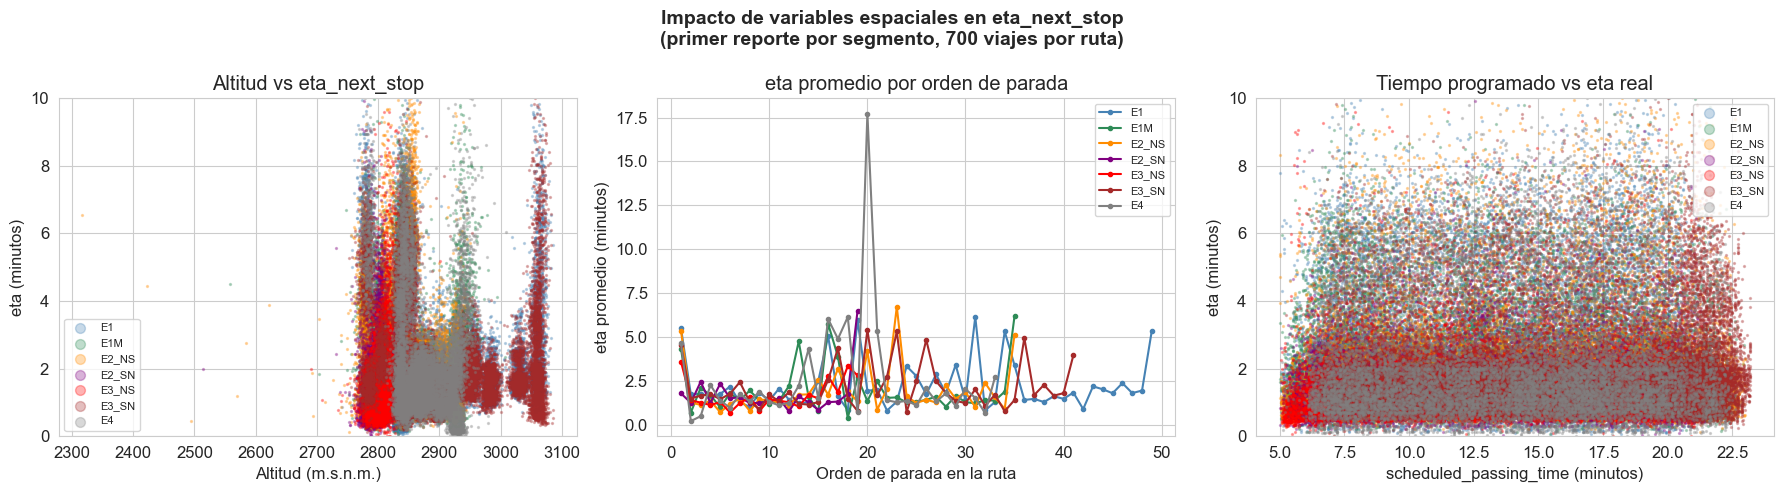


CORRELACIÓN CON eta_next_stop POR RUTA

Ruta E1:
  current_stop_order          0.0465
  scheduled_passing_time      0.0071
  altitude                    0.0012

Ruta E1M:
  current_stop_order         -0.0025
  altitude                   -0.0095
  scheduled_passing_time     -0.0280

Ruta E2_NS:
  altitude                    0.1065
  current_stop_order          0.0844
  scheduled_passing_time     -0.0036

Ruta E2_SN:
  current_stop_order          0.1330
  altitude                    0.0553
  scheduled_passing_time     -0.0068

Ruta E3_NS:
  altitude                    0.2933
  scheduled_passing_time      0.0628
  current_stop_order          0.0485

Ruta E3_SN:
  current_stop_order          0.0510
  scheduled_passing_time      0.0031
  altitude                   -0.0333

Ruta E4:
  scheduled_passing_time      0.0477
  current_stop_order          0.0170
  altitude                   -0.2948


17757

In [9]:
# =============================================================
# Análisis del impacto de variables espaciales y de parada
# Se analiza el impacto de la altitud, orden de parada
# y tiempo programado en eta_next_stop por ruta.
# Se procesan 700 viajes por ruta de forma secuencial
# =============================================================

import gc
gc.collect()

resultados_espaciales = {}

for route_id, nombre_ruta in rutas_nombres.items():

    df_ruta_orig = df[df['route_id'] == route_id]
    viajes_ruta  = df_ruta_orig['trip_id'].drop_duplicates()
    n = min(700, len(viajes_ruta))
    viajes_muestra = viajes_ruta.sample(n=n, random_state=42)
    df_muestra = df_ruta_orig[df_ruta_orig['trip_id'].isin(viajes_muestra)].copy()
    df_muestra['timestamp'] = pd.to_datetime(df_muestra['timestamp'])

    df_seg = (df_muestra.sort_values('timestamp')
                        .groupby(['trip_id', 'current_stop_id'])
                        .first()
                        .reset_index())

    resultados_espaciales[nombre_ruta] = df_seg[[
        'altitude', 'current_stop_order',
        'scheduled_passing_time', 'eta_next_stop'
    ]].copy()

    del df_ruta_orig, df_muestra, df_seg
    gc.collect()

print(" Datos espaciales procesados por ruta")

# =============================================================
# Gráficas — variables espaciales vs eta
# =============================================================
colores = ['steelblue', 'seagreen', 'darkorange',
           'purple', 'red', 'brown', 'gray']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impacto de variables espaciales en eta_next_stop\n'
             '(primer reporte por segmento, 700 viajes por ruta)',
             fontsize=14, fontweight='bold')

for (nombre_ruta, datos), color in zip(
        resultados_espaciales.items(), colores):

    axes[0].scatter(datos['altitude'], datos['eta_next_stop'],
                    alpha=0.3, s=2, color=color, label=nombre_ruta)

    eta_orden = datos.groupby('current_stop_order')['eta_next_stop'].mean()
    axes[1].plot(eta_orden.index, eta_orden.values,
                 color=color, marker='o', markersize=3, label=nombre_ruta)

    axes[2].scatter(datos['scheduled_passing_time'], datos['eta_next_stop'],
                    alpha=0.3, s=2, color=color, label=nombre_ruta)

axes[0].set_title('Altitud vs eta_next_stop')
axes[0].set_xlabel('Altitud (m.s.n.m.)')
axes[0].set_ylabel('eta (minutos)')
axes[0].set_ylim(0, 10)
axes[0].legend(markerscale=5, fontsize=8)

axes[1].set_title('eta promedio por orden de parada')
axes[1].set_xlabel('Orden de parada en la ruta')
axes[1].set_ylabel('eta promedio (minutos)')
axes[1].legend(fontsize=8)

axes[2].set_title('Tiempo programado vs eta real')
axes[2].set_xlabel('scheduled_passing_time (minutos)')
axes[2].set_ylabel('eta (minutos)')
axes[2].set_ylim(0, 10)
axes[2].legend(markerscale=5, fontsize=8)

plt.tight_layout()
plt.savefig('espaciales_vs_eta.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================
# Correlación numérica por ruta
# =============================================================
cols_espaciales = ['altitude', 'current_stop_order', 'scheduled_passing_time']

print("\n" + "=" * 60)
print("CORRELACIÓN CON eta_next_stop POR RUTA")
print("=" * 60)

for nombre_ruta, datos in resultados_espaciales.items():
    corr = datos[cols_espaciales + ['eta_next_stop']].corr()['eta_next_stop'].drop('eta_next_stop')
    print(f"\nRuta {nombre_ruta}:")
    for var, val in corr.sort_values(ascending=False).items():
        print(f"  {var:<25} {val:>8.4f}")

del resultados_espaciales
gc.collect()

## Hallazgos - Variables espaciales

El análisis confirmó que la altitud presenta correlaciones 
contradictorias entre rutas (E3_NS: +0.29, E4: -0.29), 
por lo que se descarta del modelo al no mostrar un patrón 
consistente.

El tiempo programado (scheduled_passing_time) presenta 
correlaciones casi nulas con el eta real (entre -0.03 y 0.06), 
confirmando empíricamente que el horario programado del sistema 
Ecovía no predice el comportamiento real de la operación. 
Este hallazgo justifica la necesidad de un modelo predictivo 
basado en datos históricos reales.

## Conclusiones del Análisis Exploratorio de Datos

### 1. Calidad del dataset
- **28,011,776 registros** analizados sin valores nulos en eta_next_stop
- Sin valores negativos ni ceros en eta_next_stop
- **136 valores nulos** en acceleration (0.0005% del dataset) → se rellenan con 0
- **is_holiday = False** en todos los registros → error del dataset, requiere corrección
- **501,004 registros** con eta > 10 minutos → outliers a eliminar
- **42,341 registros** con eta > 60 minutos → imposibles operacionalmente

### 2. Variable objetivo: eta_next_stop
- Promedio: **1.83 minutos** | Mediana: **0.98 minutos** | Máximo: **138.03 minutos**
- El **98.21%** de los registros tienen eta ≤ 10 minutos
- Umbral de limpieza definido por ruta basado en el percentil 99% de cada ruta

### 3. Variables temporales
| Variable | Impacto | Decisión |
|---|---|---|
| hour | Alto | ✅ Incluir |
| is_peak_hour | Medio (5 de 7 rutas) | ✅ Incluir |
| is_weekend | Pequeño (6 de 7 rutas) | ✅ Incluir |
| day_of_week | Mínimo pero consistente | ✅ Incluir |
| is_holiday | Requiere corrección | ✅ Incluir post-corrección |

### 4. Variables operacionales
| Variable | Correlación máx. | Decisión |
|---|---|---|
| distance_to_next_stop | 0.80 (E4) | ✅ Incluir — más importante |
| speed | Baja (< 0.10) | ✅ Incluir |
| acceleration | Baja (< 0.13) | ✅ Incluir |
| time_since_last_stop | Baja (< 0.11) | ✅ Incluir |

### 5. Variables espaciales y de parada
| Variable | Correlación | Decisión |
|---|---|---|
| current_stop_id | — | ✅ Incluir |
| current_stop_order | Baja (< 0.13) | ✅ Incluir |
| altitude | Contradictoria entre rutas | ❌ Excluir |
| scheduled_passing_time | Casi nula (< 0.06) | ❌ Excluir |

### 6. Variables seleccionadas para el modelo
| Variable | Categoría | Importancia |
|---|---|---|
| current_stop_id | Espacial | Alta |
| current_stop_order | Espacial | Media |
| distance_to_next_stop | Espacial | Muy alta |
| speed | Operacional | Media |
| acceleration | Operacional | Baja |
| time_since_last_stop | Operacional | Baja |
| hour | Temporal | Alta |
| day_of_week | Temporal | Baja |
| is_weekend | Temporal | Baja |
| is_peak_hour | Temporal | Media |
| is_holiday | Temporal | Media |

**Total: 11 variables predictoras | Variable objetivo: eta_next_stop | route_id: se utiliza para segmentar datos por ruta**

### 7. Acciones de preprocesamiento definidas
1. Eliminar registros con valid = False
2. Eliminar registros con speed = 0 (buses detenidos)
3. Convertir speed de knots a km/h (× 1.852)
4. Eliminar registros con speed > 60 km/h (errores GPS)
5. Eliminar outliers de eta por ruta (percentil 99%)
6. Corregir is_holiday con feriados reales de Ecuador 2025-2026
7. Rellenar 136 nulos de acceleration con 0
8. Convertir variables booleanas a entero (0 y 1)
9. Normalizar variables con StandardScaler
10. Construir ventanas temporales agrupadas por route_id + trip_id + current_stop_id

> **EDA completado - Listo para preprocesamiento**

## Variables excluidas del modelo

Del dataset original de **36 variables** se excluyeron **23** por las razones detalladas a continuación.

| Variable | Categoría | Justificación de exclusión |
|---|---|---|
| bus_id | Identificación | Identifica el bus físico. Los modelos no deben aprender comportamientos de buses específicos que pueden cambiar de ruta o ser reemplazados. |
| trip_id | Identificación | Identifica el viaje específico. No se repite en el tiempo, los modelos no pueden generalizar. |
| timestamp | Temporal | Fecha y hora exacta del reporte. No se repite. Sus patrones están capturados por hour y day_of_week. |
| start_time | Temporal | Hora de inicio del viaje. No aporta información adicional a la que ya captura hour. |
| end_time | Temporal | Hora de fin del viaje. No disponible en producción al momento de predecir. |
| date | Temporal | Fecha específica del día. No se repite. Capturado por day_of_week e is_holiday. |
| latitude | Espacial | Posición GPS exacta no generaliza. Capturado por current_stop_id. |
| longitude | Espacial | Misma razón que latitude. |
| altitude | Espacial | Correlación contradictoria entre rutas (E3_NS: +0.29, E4: -0.29). Sin patrón consistente. |
| course | Operacional | Dirección en grados. Capturado por route_id y current_stop_order. |
| accuracy | Operacional | Precisión GPS. Solo se usa para filtrar. Todos los registros tienen accuracy=0. |
| valid | Operacional | Validez del registro GPS. Solo se usa para filtrar registros inválidos. |
| step_time | Operacional | Directamente relacionado con eta_next_stop. Causaría data leakage. |
| scheduled_passing_time | Operacional | Correlación casi nula con eta real (entre -0.03 y 0.06). El horario programado no refleja la operación real. |
| real_passing_time | Operacional | Hora real de llegada en formato decimal. No disponible en tiempo real en producción. |
| last_stop_time | Operacional | Timestamp de llegada a la parada actual. Capturado por time_since_last_stop. |
| bus_stop_lat | Espacial | Coordenada de la parada actual. Capturado por current_stop_id. |
| bus_stop_lng | Espacial | Misma razón que bus_stop_lat. |
| next_stop_order | Espacial | Capturado por current_stop_order + 1. |
| next_stop_id | Espacial | Los modelos predicen eta sin necesitar identificar la siguiente parada. |
| next_stop_time | Operacional | Directamente relacionado con eta_next_stop. Causaría data leakage. |
| next_stop_lat | Espacial | Capturado por distance_to_next_stop. |
| next_stop_lng | Espacial | Misma razón que next_stop_lat. |

---

| Resumen | Cantidad |
|---|---|
| Total variables en dataset | 36 |
| Variables predictoras | 11 |
| Variable objetivo | 1 (eta_next_stop) |
| Identficador de segmentación | 1 (route_id) |
| Variables excluidas | 23 |